In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
veri = pd.read_csv("temizlenmis_veri.csv")

##### **Soru 1 -- Hangi kategori hem ticari performans hem de müşteri memnuniyeti açısından en güçlü görünüyor?**

> ****Kategori bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.****

> ***Kategori bazlı özet tablo oluşturun.***

> ***Toplam gelir için bir bar plot çizdirin.***

> ***Ortalama müşteri puanı için ikinci bir bar plot çizdirin.***

> ***Hem gelir hem memnuniyet açısından en güçlü kategoriyi belirleyin ve kısa bir iş yorumu yazın.***


In [25]:
kategori_ozet = veri.groupby("kategori").agg(
    siparis_sayisi=("siparis_id", "count"),
    toplam_gelir=("toplam_tutar", "sum"),
    ortalama_siparis_tutari=("toplam_tutar", "mean"),
    ortalama_musteri_puani=("musteri_puani", "mean"),
    ortalama_teslimat_gunu=("teslimat_gunu", "mean")
).sort_values("toplam_gelir", ascending=False)

kategori_ozet

,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
kategori,,,,,
Elektronik,241,765989.55,3178.379876,4.058091,3.298755
Spor,235,331770.62,1411.789872,3.991489,3.173160
Ofis,230,291376.57,1266.854652,3.908696,3.418919
Kozmetik,223,203726.63,913.572332,4.143498,3.336406
Ev ve Yaşam,216,187901.01,869.912083,3.902778,3.478469
Kitap,253,145588.25,575.447628,3.980237,3.476000


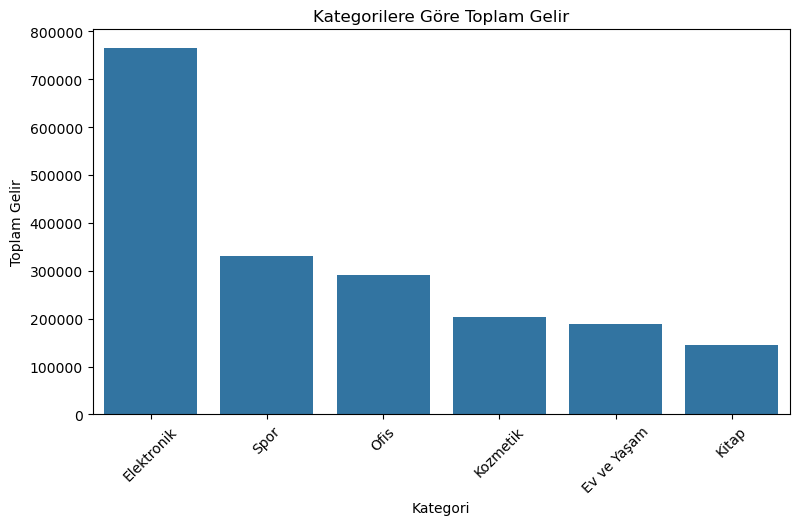

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=kategori_ozet.reset_index(),
    x="kategori",
    y="toplam_gelir"
)

plt.xlabel("Kategori")
plt.ylabel("Toplam Gelir")
plt.title("Kategorilere Göre Toplam Gelir")
plt.xticks(rotation=45)
plt.show()

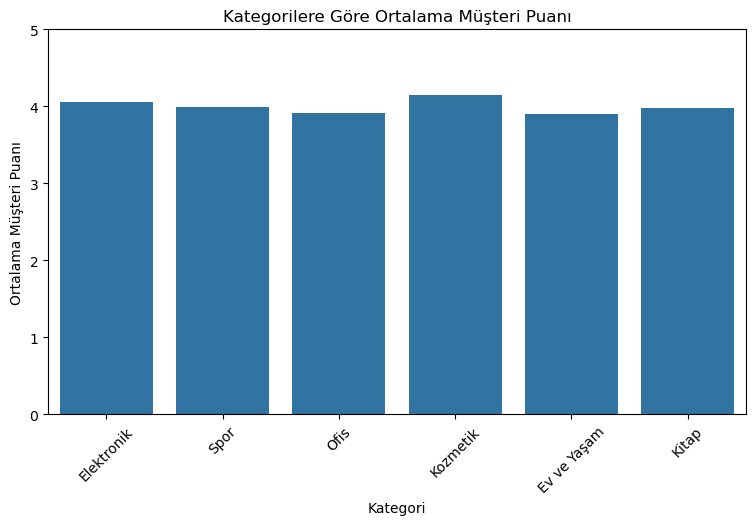

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=kategori_ozet.reset_index(),
    x="kategori",
    y="ortalama_musteri_puani"
)

plt.xlabel("Kategori")
plt.ylabel("Ortalama Müşteri Puanı")
plt.title("Kategorilere Göre Ortalama Müşteri Puanı")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.show()

**İş Yorumu:** *Kategoriler arasında ticari performans açısından en güçlü kategori Elektronik'tir. 765.989,55 TL toplam gelir ve 3.178,38 TL ortalama sipariş tutarı ile diğer kategorilerin belirgin şekilde önünde yer alırken, 4,06 ortalama müşteri puanı ile müşteri memnuniyeti açısından da güçlü bir performans göstermektedir. Kozmetik 4,14 ile en yüksek müşteri puanına sahip olsa da gelir performansı Elektronik'in oldukça gerisindedir. Bu nedenle Elektronik kategorisi, hem gelir yaratma hem de müşteri memnuniyetini koruma açısından en güçlü kategori olarak değerlendirilebilir.*

##### **Soru 2 -- Hangi şehirler daha yüksek potansiyel taşıyor?**

> ****Şehir bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.****

> ***Şehir bazlı özet tablo oluşturun.***

> ***Toplam gelire göre şehirleri büyükten küçüğe sıralayın.***

> ***En güçlü 5 şehir için bir bar plot çizdirin.***

> ***Müşteri puanı yüksek ama gelir açısından geride kalan şehirleri ayrıca tespit edin ve büyüme adayı şehirler için kısa bir yorum yazın.***


In [33]:
sehir_ozet = veri.groupby("sehir").agg(
    siparis_sayisi=("siparis_id", "count"),
    toplam_gelir=("toplam_tutar", "sum"),
    ortalama_siparis_tutari=("toplam_tutar", "mean"),
    ortalama_musteri_puani=("musteri_puani", "mean")
).sort_values("toplam_gelir", ascending=False)

sehir_ozet

,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
sehir,,,,
İstanbul,302,425119.62,1407.680861,4.115894
Ankara,169,272952.97,1615.106331,3.828402
İzmir,154,184523.39,1198.203831,3.889610
Antalya,108,129851.32,1202.327037,4.027778
Mersin,57,113273.31,1987.251053,4.105263
Kayseri,54,111551.65,2065.771296,3.907407
Gaziantep,66,107211.78,1624.420909,4.030303
Konya,87,101798.84,1170.101609,4.218391
Bursa,86,98335.67,1143.438023,3.988372


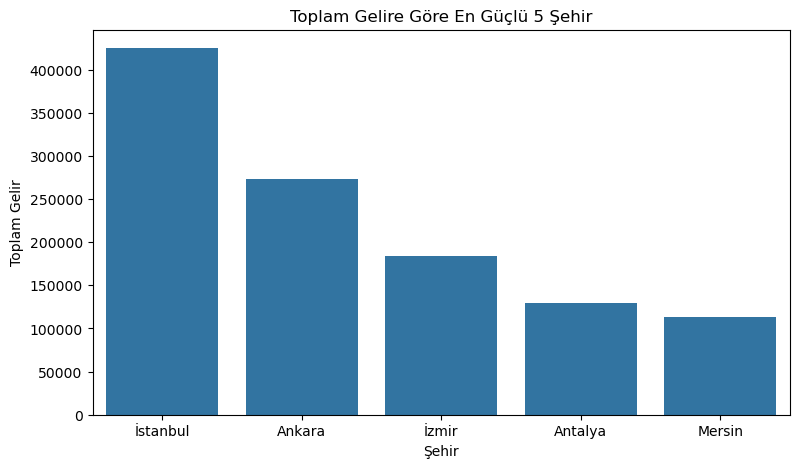

In [35]:
en_guclu_5_sehir = sehir_ozet.head(5).reset_index()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=en_guclu_5_sehir,
    x="sehir",
    y="toplam_gelir"
)

plt.xlabel("Şehir")
plt.ylabel("Toplam Gelir")
plt.title("Toplam Gelire Göre En Güçlü 5 Şehir")
plt.show()

**İş Yorumu:** *İstanbul, 425.119,62 TL toplam gelir ve 302 sipariş ile şehirler arasında açık ara en güçlü ticari performansa sahiptir. Ankara ve İzmir de yüksek gelir üreten şehirler olurken, Mersin 57 siparişe rağmen 113.273,31 TL gelir ve 1.987,25 TL ortalama sipariş tutarıyla dikkat çekmektedir. Bunun yanında Konya, Adana ve Samsun gibi şehirlerde müşteri memnuniyeti yüksek olmasına rağmen toplam gelir daha düşük seviyededir. Bu şehirler, mevcut müşteri memnuniyetinden yararlanılarak satış hacmini artırmaya yönelik kampanya ve pazarlama çalışmaları açısından büyüme adayı olarak değerlendirilebilir.*

##### **Soru 3 -- Hangi ödeme türü daha değerli müşteri davranışı üretiyor?**

> ****Ödeme türü bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.****

> ***Ödeme türüne göre özet tablo oluşturun.***

> ***Ortalama sipariş tutarı için bir bar plot çizdirin.***

> ***Ortalama müşteri puanı için ikinci bir bar plot çizdirin.***

> ***En yüksek gelir üreten ödeme türü ile en yüksek memnuniyet üreten ödeme türünü karşılaştırın ve sonucu iş diliyle yorumlayın***


In [39]:
odeme_ozet = veri.groupby("odeme_turu").agg(
    siparis_sayisi=("siparis_id", "count"),
    toplam_gelir=("toplam_tutar", "sum"),
    ortalama_siparis_tutari=("toplam_tutar", "mean"),
    ortalama_musteri_puani=("musteri_puani", "mean"),
    ortalama_teslimat_gunu=("teslimat_gunu", "mean")
).sort_values("toplam_gelir", ascending=False)

odeme_ozet

,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
odeme_turu,,,,,
Kredi Kartı,706,933059.43,1321.613924,4.043909,3.414244
Dijital Cüzdan,192,317562.26,1653.970104,4.052083,3.276596
Banka Kartı,211,287577.59,1362.926967,3.824645,3.485577
Havale/EFT,141,216729.94,1537.091773,3.921986,3.178571
Kapıda Ödeme,95,101704.21,1070.570632,4.052632,3.193548
Kart,14,25167.67,1797.690714,4.214286,3.357143
banka karti,12,13754.45,1146.204167,3.583333,3.416667
dijital cüzdan,6,12924.15,2154.025000,3.500000,3.333333
kredi kartı,9,9812.42,1090.268889,4.555556,2.888889


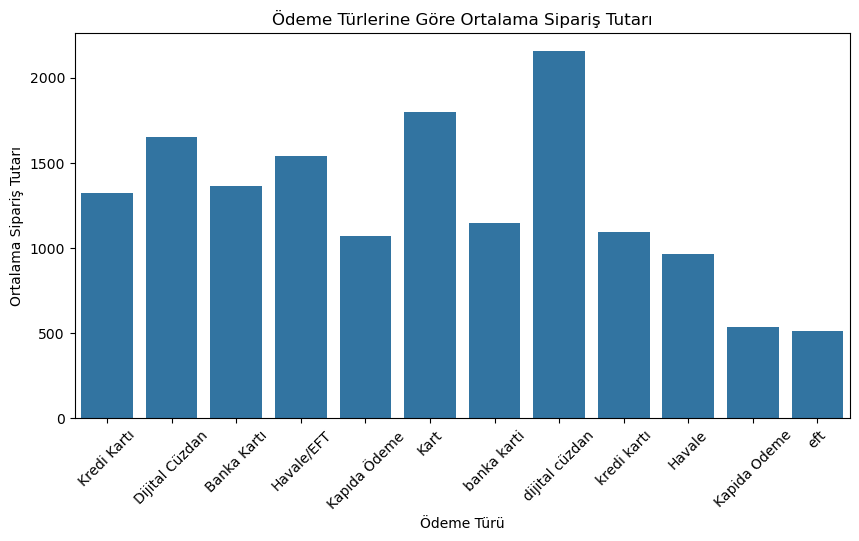

In [41]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=odeme_ozet.reset_index(),
    x="odeme_turu",
    y="ortalama_siparis_tutari"
)

plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Sipariş Tutarı")
plt.title("Ödeme Türlerine Göre Ortalama Sipariş Tutarı")
plt.xticks(rotation=45)
plt.show()

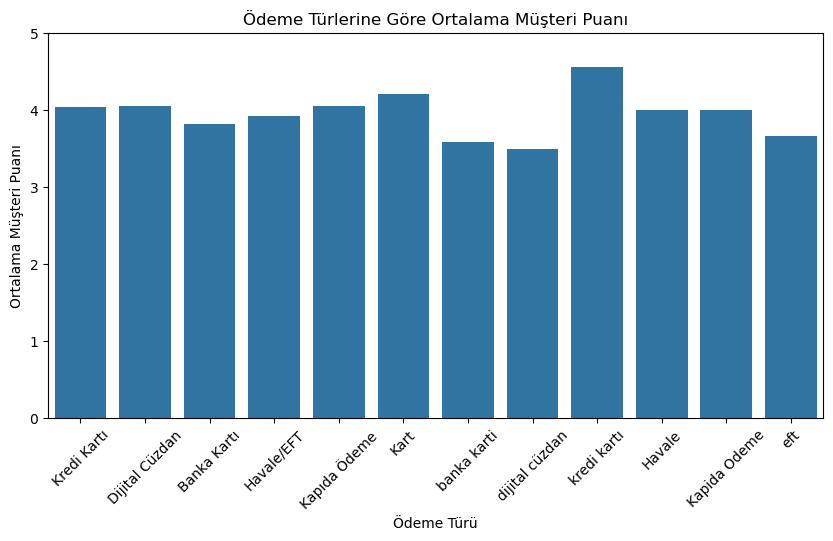

In [43]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=odeme_ozet.reset_index(),
    x="odeme_turu",
    y="ortalama_musteri_puani"
)

plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Müşteri Puanı")
plt.title("Ödeme Türlerine Göre Ortalama Müşteri Puanı")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.show()

**İş Yorumu:** *Kredi Kartı, 933.059,43 TL ile en yüksek toplam geliri üreten ödeme türüdür ve 706 siparişle en yüksek işlem hacmine sahiptir. Ortalama müşteri puanı 4,04 ile yüksek seviyede olsa da en yüksek memnuniyet değeri düşük sipariş sayılarına sahip kredi kartı grubunda görülmektedir. Yüksek işlem hacmine sahip ödeme türleri arasında Dijital Cüzdan ve Kapıda Ödeme yaklaşık 4,05 puan ile öne çıkmaktadır. Bu nedenle Kredi Kartı mevcut gelir açısından en değerli ödeme türü olurken, Dijital Cüzdan ve Kapıda Ödeme müşteri memnuniyeti açısından dikkat çeken alternatiflerdir.*

##### **Soru 4 -- Zaman içinde satış davranışı nasıl değişiyor?**

> ****Siparis_tarihi sütununu uygun veri tipine dönüştürün.****

> ***Ay bazında sipariş sayısı, toplam gelir ve ortalama sipariş tutarı metriklerini çıkarın.***

> ***Sipariş sayısı için bir line plot çizdirin.***

> ***Toplam gelir için ikinci bir line plot çizdirin.***

> ***En yoğun ay ile en yüksek gelir elde edilen ayı karşılaştırın ve “sipariş artışı ile gelir artışı aynı dönemde mi gerçekleşiyor?” sorusuna yorum yapın.***

In [47]:
veri["siparis_tarihi"] = pd.to_datetime(veri["siparis_tarihi"])

In [49]:
aylik_ozet = veri.groupby(
    veri["siparis_tarihi"].dt.to_period("M")
).agg(
    siparis_sayisi=("siparis_id", "count"),
    toplam_gelir=("toplam_tutar", "sum"),
    ortalama_siparis_tutari=("toplam_tutar", "mean")
)

aylik_ozet.index = aylik_ozet.index.astype(str)

aylik_ozet

,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari
siparis_tarihi,,,
2024-01,56,74857.07,1336.733393
2024-02,53,63391.33,1196.062830
2024-03,64,78305.64,1223.525625
2024-04,74,70563.89,953.566081
2024-05,50,91193.79,1823.875800
2024-06,54,49269.54,912.398889
2024-07,50,64465.23,1289.304600
2024-08,54,77081.84,1427.441481
2024-09,56,59045.79,1054.389107


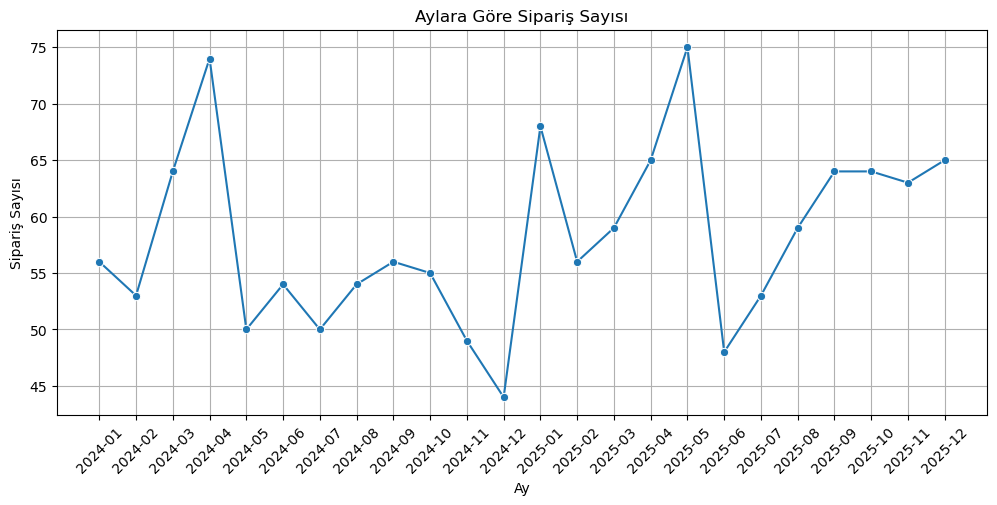

In [51]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=aylik_ozet,
    x=aylik_ozet.index,
    y="siparis_sayisi",
    marker="o"
)

plt.xlabel("Ay")
plt.ylabel("Sipariş Sayısı")
plt.title("Aylara Göre Sipariş Sayısı")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

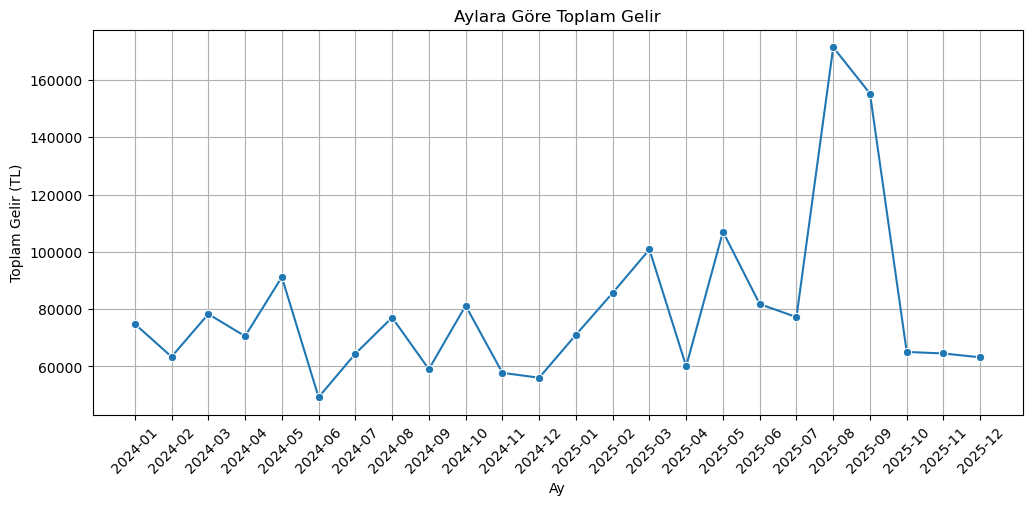

In [53]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=aylik_ozet,
    x=aylik_ozet.index,
    y="toplam_gelir",
    marker="o"
)

plt.xlabel("Ay")
plt.ylabel("Toplam Gelir (TL)")
plt.title("Aylara Göre Toplam Gelir")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**İş Yorumu:** *En yüksek sipariş sayısına Mayıs 2025'te 75 sipariş ile ulaşılırken, en yüksek toplam gelir Ağustos 2025'te 171.408,65 TL olarak gerçekleşmiştir. Bu iki zirvenin farklı aylarda ortaya çıkması, sipariş sayısındaki artış ile gelir artışının aynı dönemde gerçekleşmediğini göstermektedir. Özellikle Ağustos ve Eylül 2025'te sipariş sayısı 59 ve 64 olmasına rağmen ortalama sipariş tutarlarının sırasıyla 2.905 TL ve 2.426 TL'ye yükselmesi, gelir artışında sipariş hacminden çok sipariş başına harcama tutarının etkili olduğunu göstermektedir. Bu nedenle işletme açısından yalnızca sipariş sayısının değil, ortalama sipariş tutarının da birlikte takip edilmesi önemlidir.*

##### **Soru 5 -- Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?**

> ****sehir ve kategori kırılımında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.****

> ***En güçlü 10 şehir-kategori kombinasyonunu bulun.***

> ***Bu kombinasyonları göstermek için uygun bir bar plot oluşturun.***

> ***En güçlü kombinasyonu belirleyin.***

> ***Bu bulgunun pazarlama, kampanya veya ürün stratejisi açısından ne anlama gelebileceğini yorumlayın.***

In [57]:
sehir_kategori_ozet = veri.groupby(["sehir", "kategori"]).agg(
    siparis_sayisi=("siparis_id", "count"),
    toplam_gelir=("toplam_tutar", "sum"),
    ortalama_siparis_tutari=("toplam_tutar", "mean"),
    ortalama_musteri_puani=("musteri_puani", "mean")
).reset_index()

sehir_kategori_ozet

,sehir,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
0,Adana,Elektronik,12,37546.60,3128.883333,4.416667
1,Adana,Ev ve Yaşam,8,8922.99,1115.373750,3.875000
2,Adana,Kitap,12,5811.48,484.290000,4.000000
3,Adana,Kozmetik,18,10260.15,570.008333,4.277778
4,Adana,Ofis,13,5415.80,416.600000,3.769231
...,...,...,...,...,...,...
79,İzmir,Ev ve Yaşam,21,15747.53,749.882381,3.952381
80,İzmir,Kitap,24,13459.72,560.821667,3.875000
81,İzmir,Kozmetik,19,13015.22,685.011579,4.105263
82,İzmir,Ofis,28,26005.61,928.771786,3.964286


In [59]:
en_guclu_10 = sehir_kategori_ozet.sort_values(
    "toplam_gelir",
    ascending=False
).head(10)

en_guclu_10

,sehir,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
72,İstanbul,Elektronik,61,201081.46,3296.417377,4.016393
6,Ankara,Elektronik,30,107882.67,3596.089000,3.900000
78,İzmir,Elektronik,28,79717.08,2847.038571,3.892857
77,İstanbul,Spor,53,75054.54,1416.123396,4.056604
10,Ankara,Ofis,26,67523.02,2597.039231,3.615385
36,Kayseri,Elektronik,11,58959.61,5359.964545,4.090909
48,Konya,Elektronik,19,55391.63,2915.348947,4.368421
12,Antalya,Elektronik,16,52797.02,3299.813750,4.000000
76,İstanbul,Ofis,44,48977.11,1113.116136,4.181818
35,Gaziantep,Spor,18,44823.00,2490.166667,3.888889


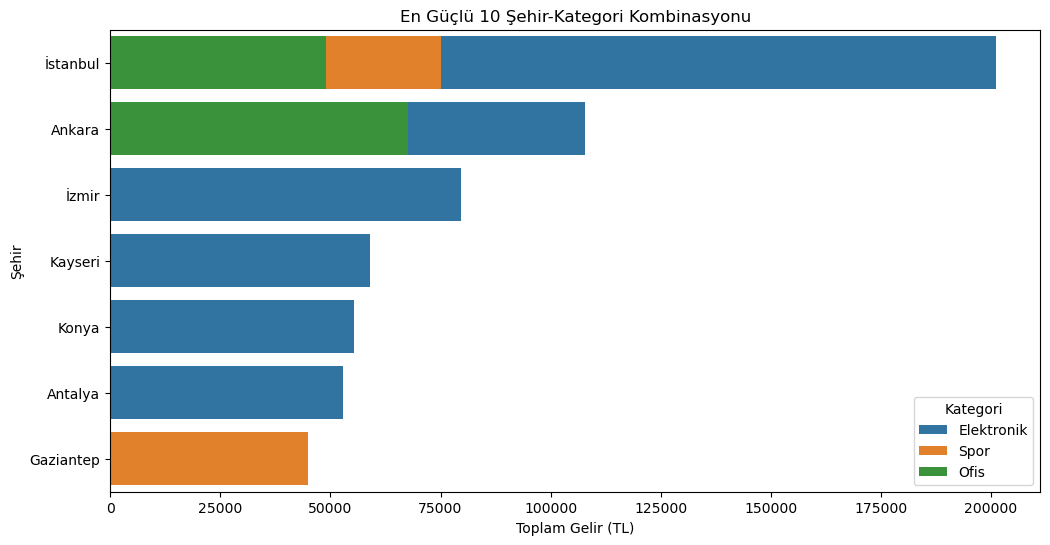

In [61]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=en_guclu_10,
    x="toplam_gelir",
    y="sehir",
    hue="kategori",
    dodge=False
)

plt.xlabel("Toplam Gelir (TL)")
plt.ylabel("Şehir")
plt.title("En Güçlü 10 Şehir-Kategori Kombinasyonu")
plt.legend(title="Kategori")
plt.show()

**İş Yorumu:** *Şehir-kategori bazında en güçlü kombinasyon, 201.081,46 TL toplam gelir ve 61 sipariş ile İstanbul–Elektronik grubudur. Elektronik kategorisinin ilk 10 kombinasyonun büyük bölümünde yer alması, farklı şehirlerde güçlü bir gelir potansiyeline sahip olduğunu göstermektedir. İstanbul'da elektronik kategorisinin yanı sıra spor ve ofis kategorilerinin de öne çıkması, bu şehirde kategori çeşitliliğinin yüksek olduğunu göstermektedir. Kayseri–Elektronik kombinasyonu ise yalnızca 11 siparişle 58.959,61 TL gelir ve 5.359,96 TL ortalama sipariş tutarına ulaşarak yüksek değerli satış potansiyeli açısından dikkat çekmektedir. Bu bulgular doğrultusunda elektronik kategorisinde şehir bazlı kampanyalar geliştirilebilir; özellikle yüksek ortalama sipariş tutarına sahip şehirlerde daha yüksek değerli ürünlerin ve hedefli kampanyaların öne çıkarılması değerlendirilebilir.*